## Tarea 3: ¿Cómo vamos a entrenar la RN? — Soluciones (parte práctica)

Soluciones de los ejercicios de Python de la tarea de práctica. La numeración corresponde a la versión actual de `tareas/Tarea3.ipynb`. Úsalas para verificar tu trabajo (o el de tu agente) **después** de intentarlo.

### Ejercicios de Python: 

1. Regresión de Poisson: usa la función de acá abajo para generar datos sintéticos de conteos de peatones (número de peatones por minuto en un punto de la ciudad, según hora del día, ubicación y tipo de colonia). Implementa el modelo en Pytorch que prediga $s = f(x,\phi)$ y use $\lambda = e^s$. Entrena con la pérdida de Poisson. Compara entrenar con SGD y con Adam. Asegurate de graficar las curvas de pérdida por época para SGD y Adam y contesta que optimizador converge más rápido y por que? 



**Respuesta:**

a. Con la misma tasa de aprendizaje:
Adam típicamente lidera en velocidad de convergencia; SGD puro puede ser ruidoso; SGD+momentum intermedio.
- Adam: suele bajar rápidamente la pérdida desde las primeras épocas. Adam adapta pasos por coordenada y usa momentos; por eso con lr=1e-2 converge de forma estable y rápida en muchos problemas.
- SGD (sin momentum) con lr=1e-2: puede ser muy ruidoso o incluso inestable (oscilaciones) si la topología del problema hace que ese lr sea demasiado grande para la estimación del gradiente por minibatch. En algunos datasets sencillos 1e-2 funciona, pero con MLP y Poisson podría provocar oscilaciones.
- SGD + momentum con lr=1e-2: en general mejora sobre SGD puro; momentum apoya la dirección de descenso y suaviza oscilaciones, por eso suele converger más rápido/estable que SGD puro.

b. Con distintas tasas de aprendizaje: 
Al reducir lr para SGD y SGD_momentum:
- SGD: se vuelve más estable (menos oscilaciones) pero más lento al bajar la pérdida. Con 1e-3 suele converger suavemente.
- SGD + momentum: con lr más pequeño puede aún aprovechar momentum para converger razonablemente y con estabilidad.
- Adam (se mantiene 1e-2): seguirá siendo rápido. Como Adam ajusta pasos por coordenada, muchas veces tolera lr más grande sin divergir.

c. Interpretación práctica:
- Tasa de aprendizaje (lr) es el hiperparámetro más crítico: un lr demasiado grande produce inestabilidad o divergencia; demasiado pequeño, entrenas muy lento.
- Momentum actúa como amortiguador y, si se combina con lr moderado, acelera la convergencia y reduce oscilaciones.
- Adam es robusto a la elección de lr relativa y suele converger rápido en problemas pequeños/medianos; sin embargo, no garantiza mejor generalización y puede requerir ajuste fino en problemas grandes.

Comparación justa: importante reusar la misma inicialización de parámetros (como hace el código) para aislar el efecto del optimizador y la lr.

/var/folders/bl/8nlz54wj6vz1h95x_pcnxjc40000gn/T/ipykernel_21444/1065433210.py:34: RuntimeWarning: overflow encountered in exp
  lam = np.clip(np.exp(s), 1e-6, 50.0)


X1.shape = torch.Size([2000, 7])  y1.shape = torch.Size([2000, 1])
Entrenando P1 con SGD
Entrenando P1 con SGD_momentum
Entrenando P1 con Adam
SGD            | len=80 | first=2.085e+04 | last=2.153e+04 | min=2.085e+04 | max=2.153e+04 | any_nan=False | any_inf=False
SGD_momentum   | len=80 | first=2.085e+04 | last=2.153e+04 | min=2.085e+04 | max=2.153e+04 | any_nan=False | any_inf=False
Adam           | len=80 | first=655.2 | last=-145.5 | min=-146.3 | max=655.2 | any_nan=False | any_inf=False


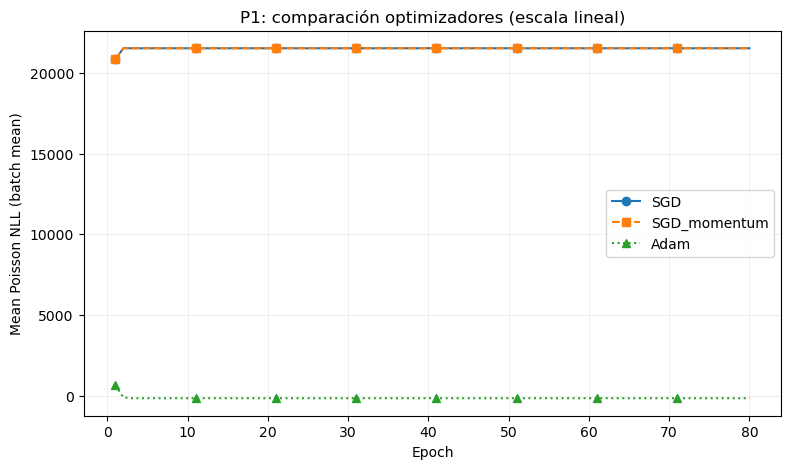

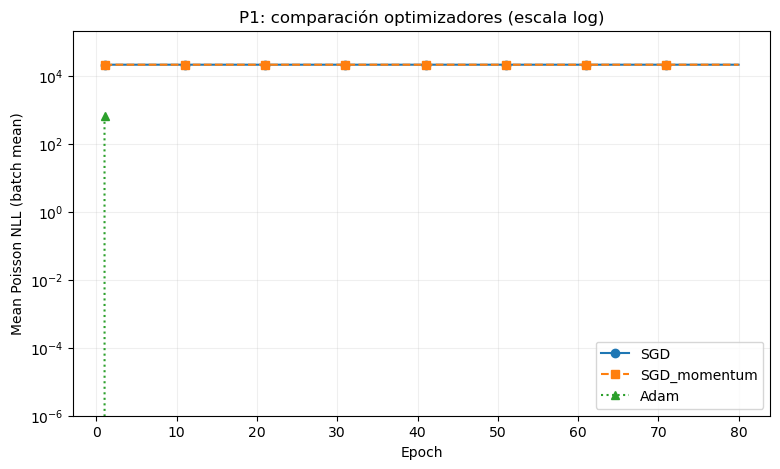


Predicciones (primeros 8) por optimizador:

SGD:
  0: lambda=485165184.000, y=47
  1: lambda=485165184.000, y=60
  2: lambda=485165184.000, y=46
  3: lambda=485165184.000, y=46
  4: lambda=485165184.000, y=61
  5: lambda=485165184.000, y=56
  6: lambda=485165184.000, y=65
  7: lambda=485165184.000, y=57

SGD_momentum:
  0: lambda=485165184.000, y=47
  1: lambda=485165184.000, y=60
  2: lambda=485165184.000, y=46
  3: lambda=485165184.000, y=46
  4: lambda=485165184.000, y=61
  5: lambda=485165184.000, y=56
  6: lambda=485165184.000, y=65
  7: lambda=485165184.000, y=57

Adam:
  0: lambda=51.149, y=47
  1: lambda=51.272, y=60
  2: lambda=51.832, y=46
  3: lambda=51.910, y=46
  4: lambda=51.816, y=61
  5: lambda=52.046, y=56
  6: lambda=51.367, y=65
  7: lambda=51.229, y=57


In [9]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibilidad: fija la semilla
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)
device = torch.device("cpu")

def generate_p1_data(N=2000):
    rng = np.random.RandomState(0)
    hours = rng.randint(0, 24, size=(N, 1)).astype(np.float32)
    hour_rad = 2 * math.pi * hours / 24.0
    hour_sin = np.sin(hour_rad).astype(np.float32)
    hour_cos = np.cos(hour_rad).astype(np.float32)
    lat = (40.0 + rng.normal(scale=0.01, size=(N,1))).astype(np.float32)
    lon = (-74.0 + rng.normal(scale=0.01, size=(N,1))).astype(np.float32)
    neigh = rng.randint(0, 3, size=(N,))
    neigh_onehot = np.zeros((N,3), dtype=np.float32)
    neigh_onehot[np.arange(N), neigh] = 1.0

    X = np.concatenate([hour_sin, hour_cos, lat, lon, neigh_onehot], axis=1)
    w = np.array([0.8, -0.6, 30.0, -20.0, 0.5, 0.2, -0.1], dtype=np.float32)
    s_linear = X @ w.reshape(-1,1)
    rush = 1.0 * np.exp(-((hours - 8)**2)/8.0) + 1.2 * np.exp(-((hours - 18)**2)/10.0)
    s = s_linear + 0.3 * rush
    lam = np.clip(np.exp(s), 1e-6, 50.0)
    y = rng.poisson(lam).astype(np.float32)  # shape (N,1)

    return torch.from_numpy(X).float(), torch.from_numpy(y).float(), {'w_true': w}

# Modelo y funciones
class PoissonNet(nn.Module):
    def __init__(self, in_dim, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

def poisson_nll_from_logits(s, y):
    # Asegura que y tenga la misma forma que s (batch,1)
    if y.dim() == 1:
        y = y.view(-1, 1)
    else:
        y = y.view_as(s)
    # prevenir overflow en exp: limitar s antes de exp
    s_clamped = torch.clamp(s, -20.0, 10.0)  # evita exp(s) gigantes
    return (torch.exp(s_clamped) - y * s_clamped).mean()

def train_poisson(X, y, optimizer_factory, lr=1e-2, epochs=80, batch_size=64):
    set_seed(42)  # misma inicialización para comparación justa
    model = PoissonNet(X.shape[1], hidden=32)
    optimizer = optimizer_factory(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)
    history = []
    for ep in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            s = model(xb)
            loss = poisson_nll_from_logits(s, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        history.append(np.mean(batch_losses))
    return model, history

# Generar datos
X1, y1, meta = generate_p1_data(N=2000)
print("X1.shape =", X1.shape, " y1.shape =", y1.shape)

# Factories
optim_factories = {
    'SGD': lambda params, lr: optim.SGD(params, lr=lr),
    'SGD_momentum': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    'Adam': lambda params, lr: optim.Adam(params, lr=lr)
}

# Entrenar
results_p1 = {}
for name, factory in optim_factories.items():
    print("Entrenando P1 con", name)
    model, hist = train_poisson(X1, y1, optimizer_factory=factory, lr=0.01, epochs=80, batch_size=64)
    results_p1[name] = {'model': model, 'history': np.array(hist)}

# Resumen rápido (debug)
for name, v in results_p1.items():
    h = v['history']
    print(f"{name:14s} | len={len(h):2d} | first={h[0]:.4g} | last={h[-1]:.4g} | min={np.nanmin(h):.4g} | max={np.nanmax(h):.4g} | any_nan={np.isnan(h).any()} | any_inf={np.isinf(h).any()}")

# Preparar para graficar: limpiar NaN/Inf y normalizar visualmente
plt.figure(figsize=(9,5))
linestyles = {'SGD':'-', 'SGD_momentum':'--', 'Adam':':'}
markers = {'SGD':'o', 'SGD_momentum':'s', 'Adam':'^'}

# Construir una matriz de todas las pérdidas para estimar un rango razonable
all_hist = np.concatenate([v['history'] for v in results_p1.values()])
# si todo explota, usar percentiles robustos
ymin, ymax = np.nanpercentile(all_hist[np.isfinite(all_hist)], [1, 99]) if np.any(np.isfinite(all_hist)) else (0.0, 1.0)

for name, v in results_p1.items():
    h = v['history'].copy()
    # reemplaza inf por un valor grande y NaN por nanmedian
    if np.isinf(h).any():
        h[np.isposinf(h)] = np.nanmax(h[np.isfinite(h)]) if np.any(np.isfinite(h)) else 1e6
        h[np.isneginf(h)] = np.nanmin(h[np.isfinite(h)]) if np.any(np.isfinite(h)) else -1e6
    if np.isnan(h).any():
        med = np.nanmedian(h)
        h[np.isnan(h)] = med
    # plot en escala log para ver diferencias cuando hay explosiones
    plt.plot(range(1, len(h)+1), h, label=name, linestyle=linestyles.get(name,'-'),
             marker=markers.get(name,''), markevery=10, linewidth=1.5)

plt.xlabel('Epoch')
plt.ylabel('Mean Poisson NLL (batch mean)')
plt.title('P1: comparación optimizadores (escala lineal)')
plt.legend()
plt.grid(alpha=0.2)
plt.yscale('linear')
plt.show()

# También mostrar en escala log y con límites robustos
plt.figure(figsize=(9,5))
for name, v in results_p1.items():
    h = v['history']
    plt.plot(range(1, len(h)+1), h, label=name, linestyle=linestyles.get(name,'-'),
             marker=markers.get(name,''), markevery=10, linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Mean Poisson NLL (batch mean)')
plt.title('P1: comparación optimizadores (escala log)')
plt.yscale('log')
plt.ylim(max(1e-6, ymin*0.5), ymax*10 if ymax>0 else 1.0)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Mostrar predicciones para cada optimizador (primeros 8)
print("\nPredicciones (primeros 8) por optimizador:")
for name, v in results_p1.items():
    m = v['model']
    m.eval()
    with torch.no_grad():
        s_pred = m(X1[:20])
        lam_pred = torch.exp(torch.clamp(s_pred, -20.0, 20.0)).squeeze().numpy()
        y_true = y1[:20].squeeze().numpy()
    print(f"\n{name}:")
    for i in range(8):
        print(f" {i:2d}: lambda={lam_pred[i]:.3f}, y={int(y_true[i])}")




Entrenando con SGD  lr= 0.001
Entrenando con SGD_momentum  lr= 0.001
Entrenando con Adam  lr= 0.01
SGD          | first=-143.5 | last=-145.4 | min=-145.8 | max=-143.5 | any_inf=False | any_nan=False
SGD_momentum | first=-135.8 | last=-145.3 | min=-145.7 | max=-135.8 | any_inf=False | any_nan=False
Adam         | first=479.2 | last=-145.4 | min=-146 | max=479.2 | any_inf=False | any_nan=False


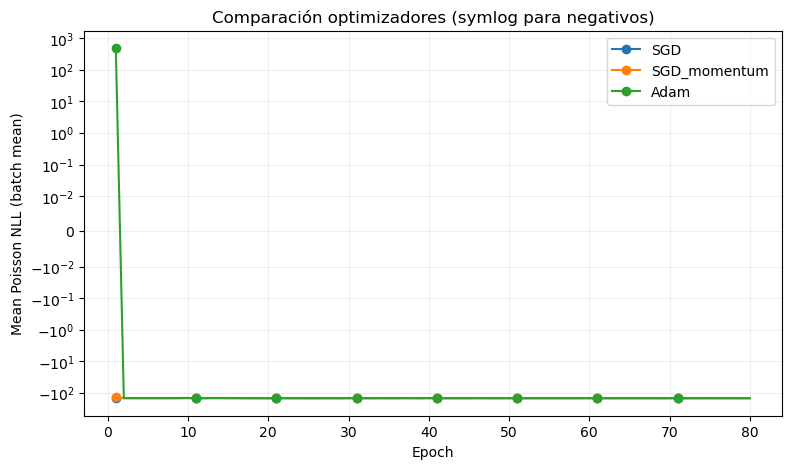

In [10]:
# Añade esto (o sustitúyelo por tu bloque de entrenamiento)
import numpy as np
import torch
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
import matplotlib.pyplot as plt

# lr distinto por optimizador
lr_map = {'SGD': 1e-3, 'SGD_momentum': 1e-3, 'Adam': 1e-2}
optim_factories = {
    'SGD': lambda params, lr: optim.SGD(params, lr=lr, weight_decay=0.0),
    'SGD_momentum': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0),
    'Adam': lambda params, lr: optim.Adam(params, lr=lr, weight_decay=0.0)
}

def train_poisson_with_clipping(X, y, optimizer_factory, lr=1e-2, epochs=80, batch_size=64, clip=5.0):
    set_seed(42)
    model = PoissonNet(X.shape[1], hidden=32)
    optimizer = optimizer_factory(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)
    history = []
    for ep in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            s = model(xb)
            loss = poisson_nll_from_logits(s, yb)  # mantiene clamp interno
            loss.backward()
            # clipping grads
            clip_grad_norm_(model.parameters(), max_norm=clip)
            optimizer.step()
            batch_losses.append(loss.item())
        history.append(np.mean(batch_losses))
    return model, np.array(history)

results_p1 = {}
for name, factory in optim_factories.items():
    lr = lr_map.get(name, 1e-2)
    print("Entrenando con", name, " lr=", lr)
    model, hist = train_poisson_with_clipping(X1, y1, factory, lr=lr, epochs=80, batch_size=64, clip=5.0)
    results_p1[name] = {'model': model, 'history': hist}

# Resumen numérico
for name, v in results_p1.items():
    h = v['history']
    print(f"{name:12s} | first={h[0]:.4g} | last={h[-1]:.4g} | min={np.nanmin(h):.4g} | max={np.nanmax(h):.4g} | any_inf={np.isinf(h).any()} | any_nan={np.isnan(h).any()}")

# Graficar con symlog para ver negativos y positivos
plt.figure(figsize=(9,5))
for name, v in results_p1.items():
    plt.plot(range(1, len(v['history'])+1), v['history'], label=name, marker='o', markevery=10)
plt.xlabel('Epoch')
plt.ylabel('Mean Poisson NLL (batch mean)')
plt.title('Comparación optimizadores (symlog para negativos)')
plt.yscale('symlog', linthresh=1e-2)   # muestra negativos y positivos
plt.grid(alpha=0.2)
plt.legend()
plt.show()

2. Generamos un dataset sintético con dos salidas: altura (metros) y peso (kilogramos). Entrena y compara dos versiones de la misma red neuronal:
- Modelo A: entrena directamente sobre targets sin normalizar.
- Modelo B: normaliza los targets (z-score) durante el entrenamiento; al evaluar des-normaliza las predicciones para reportar métricas en las unidades reales.

a. Grafica la función de pérdida (MSE) global (train y val) en unidades reales por época para ambos modelos en la misma figura

b. Grafica RMSE por salida (altura, peso) en validación por época para ambos modelos 

c. Tabla con RMSE final en validación (altura y peso) para ambos modelos

d. Explica por qué la normalización de los targets ayuda 

c. ¿Qué harias si quisieras priorizar la precisión en altura sobre el peso? (pista: piensa en la función de pérdia o normaliza de forma distinta)

d.  ¿Por qué la normalización de los targets ayuda?

La normalización (p. ej. z-score) de los targets balancea la escala de cada salida y, por tanto, la magnitud de sus gradientes durante el entrenamiento. Si una salida (peso) tiene varianza mucho mayor que otra (altura), su error domina la función de pérdida y la red “prioriza” reducir ese error. Normalizar targets:
- hace que las componentes de la pérdida tengan magnitud comparable → gradientes con magnitud más equilibrada;
- mejora el condicionamiento numérico de la optimización → convergencia más estable y rápida;
- evita que la red ignore salidas de pequeña escala (como la altura) porque su contribución a la pérdida es despreciable.

En resumen: normalizar targets ayuda a que la optimización trate ambas tareas por igual y reduce oscilaciones / sesgos en el aprendizaje.

e. ¿Qué harías si quisieras priorizar la precisión en altura sobre el peso?

Opciones prácticas (de menor a mayor sofisticación):
- Re-pesar la función de pérdida (fácil y efectivo): usar una pérdida ponderada L=α⋅MSEheight+(1−α)⋅MSEweight, con α>0.5 (por ejemplo α=0.8α=0.8) para priorizar altura.
- Normalizar pero con escala deseada: Normalizar ambos targets y luego multiplicar la componente de altura por un factor mayor antes de promediar — es equivalente a re-pesar pero trabaja en la escala normalizada.
- Técnicas dinámicas de weighting: usar métodos como uncertainty weighting (Kendall et al.), GradNorm o task-dependent learning rates para que el propio algoritmo ajuste pesos de tarea según progreso.
- Arquitectura: dar una pequeña sub-red dedicada a altura (o salida con su propia cabeza) o usar cabezas con pesos distintos y/o learning rates distintos.



P2 shapes: torch.Size([2000, 5]) torch.Size([2000, 2])
Entrenando modelo A: raw targets
Entrenando modelo B: normalized targets


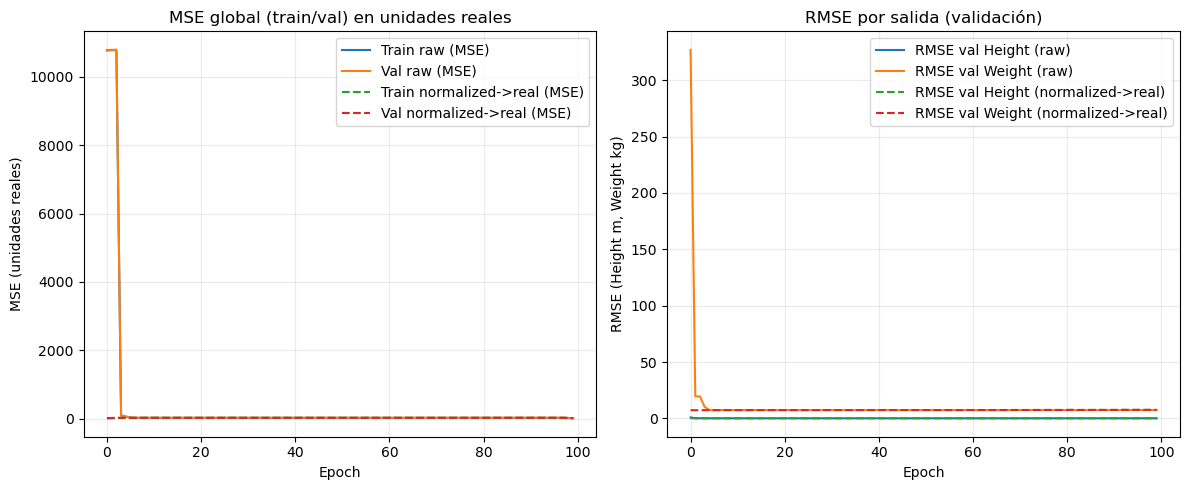

RMSE final (validación) - Modelo A (raw): Height = 0.0942 m, Weight = 7.4116 kg
RMSE final (validación) - Modelo B (normalized): Height = 0.0895 m, Weight = 7.6051 kg

Ejemplos predicciones (modelo B, de-normalizadas) primeros 6:
[[ 1.7386985 71.7644   ]
 [ 1.5934584 64.35922  ]
 [ 1.7639328 75.606384 ]
 [ 1.6586891 67.13595  ]
 [ 1.6874624 70.53488  ]
 [ 1.6653901 67.87141  ]]
Valores reales (primeros 6):
[[ 1.7216156 73.62655  ]
 [ 1.6294448 73.31826  ]
 [ 1.7233244 73.48594  ]
 [ 1.5927746 64.25566  ]
 [ 1.6817095 77.29266  ]
 [ 1.6783333 71.69496  ]]


In [4]:
import math, copy
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibilidad
# -----------------------------
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(42)

# -----------------------------
# Generador de datos (misma semilla)
# -----------------------------
def generate_p2_data(N=2000):
    rng = np.random.RandomState(1)
    X = rng.normal(size=(N,5)).astype(np.float32)
    w_h = np.array([0.02, -0.01, 0.03, 0.0, 0.01], dtype=np.float32)
    w_w = np.array([1.2, -0.8, 0.5, 0.3, 0.1], dtype=np.float32)
    height = 1.7 + X @ w_h.reshape(-1,1) + rng.normal(scale=0.08, size=(N,1)).astype(np.float32)
    weight = 70.0 + X @ w_w.reshape(-1,1) + rng.normal(scale=7.0, size=(N,1)).astype(np.float32)
    Y = np.concatenate([height, weight], axis=1).astype(np.float32)
    return torch.from_numpy(X).float(), torch.from_numpy(Y).float()

X2, Y2 = generate_p2_data(N=2000)
print("P2 shapes:", X2.shape, Y2.shape)

# -----------------------------
# Modelo
# -----------------------------
class MultiNet(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )
    def forward(self, x):
        return self.net(x)

# -----------------------------
# Función de entrenamiento mejorada
# - guarda métricas en UNIDADES REALES (de-normaliza internamente para comparar)
# - devuelve: model, train_mse_epochs, val_mse_epochs, val_rmse_each_output_epochs, predict_fn
# -----------------------------
def train_multitask_compare(X, Y, normalize_targets=False, lr=0.01, epochs=100, batch_size=64, hidden=64):
    set_seed(42)
    N = X.shape[0]
    split = int(0.8 * N)
    X_train, Y_train = X[:split], Y[:split]
    X_val, Y_val = X[split:], Y[split:]

    # target normalization on TRAIN only
    if normalize_targets:
        y_mean = Y_train.mean(dim=0, keepdim=True)
        y_std = Y_train.std(dim=0, unbiased=False, keepdim=True)
        y_std[y_std == 0] = 1.0
        Y_train_n = (Y_train - y_mean) / y_std
        Y_val_n = (Y_val - y_mean) / y_std
    else:
        y_mean = None; y_std = None
        Y_train_n, Y_val_n = Y_train, Y_val

    # Dataloaders (train uses normalized targets if requested)
    train_loader = DataLoader(TensorDataset(X_train, Y_train_n), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, Y_val_n), batch_size=batch_size, shuffle=False)

    # Model and optimizer
    model = MultiNet(X.shape[1], hidden=hidden)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.MSELoss()

    # To store metrics (in REAL UNITS): per epoch
    train_mse_epochs = []
    val_mse_epochs = []
    val_rmse_per_output_epochs = []  # list of tuples (rmse_height, rmse_weight)

    for ep in range(1, epochs+1):
        # training
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)           # loss computed on *training representation* (normalized or not)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_rep_loss = float(np.mean(batch_losses))
        # BUT we want to report train MSE in original units; compute on the whole train set
        model.eval()
        with torch.no_grad():
            preds_train = model(X_train)
            # de-normalize predictions if needed
            if normalize_targets:
                preds_train = preds_train * y_std + y_mean
            train_mse = nn.MSELoss()(preds_train, Y_train).item()
            train_mse_epochs.append(train_mse)

            # validation (do same de-normalization)
            preds_val = model(X_val)
            if normalize_targets:
                preds_val = preds_val * y_std + y_mean
            val_mse = nn.MSELoss()(preds_val, Y_val).item()
            val_mse_epochs.append(val_mse)

            # RMSE per output on validation (for interpretability)
            err = (preds_val - Y_val).cpu().numpy()
            rmse_h = np.sqrt(np.mean(err[:,0]**2))
            rmse_w = np.sqrt(np.mean(err[:,1]**2))
            val_rmse_per_output_epochs.append((rmse_h, rmse_w))

    # predict function that returns de-normalized preds in real units
    def predict_real(X_in):
        model.eval()
        with torch.no_grad():
            p = model(X_in)
            if normalize_targets:
                return p * y_std + y_mean
            else:
                return p

    meta = {'y_mean': y_mean, 'y_std': y_std}
    return model, train_mse_epochs, val_mse_epochs, val_rmse_per_output_epochs, predict_real, meta

# -----------------------------
# Entrenamiento: A (raw) vs B (normalized)
# -----------------------------
epochs = 100
print("Entrenando modelo A: raw targets")
mA, trainA, valA, val_rmseA, predA, metaA = train_multitask_compare(X2, Y2, normalize_targets=False, lr=0.01, epochs=epochs, batch_size=64)
print("Entrenando modelo B: normalized targets")
mB, trainB, valB, val_rmseB, predB, metaB = train_multitask_compare(X2, Y2, normalize_targets=True, lr=0.01, epochs=epochs, batch_size=64)

# -----------------------------
# Plots: (1) global MSE train/val en unidades reales (2) RMSE por salida (validación)
# -----------------------------
def smooth(x, k=5):
    if k <= 1: return x
    return np.convolve(x, np.ones(k)/k, mode='same')

# Convert lists to arrays
trainA = np.array(trainA); valA = np.array(valA)
trainB = np.array(trainB); valB = np.array(valB)
rmseA = np.array(val_rmseA)  # shape (epochs, 2)
rmseB = np.array(val_rmseB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(smooth(trainA,5), label='Train raw (MSE)'); plt.plot(smooth(valA,5), label='Val raw (MSE)')
plt.plot(smooth(trainB,5), label='Train normalized->real (MSE)', linestyle='--'); plt.plot(smooth(valB,5), label='Val normalized->real (MSE)', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE (unidades reales)'); plt.title('MSE global (train/val) en unidades reales')
plt.legend(); plt.grid(alpha=0.25)

plt.subplot(1,2,2)
plt.plot(rmseA[:,0], label='RMSE val Height (raw)'); plt.plot(rmseA[:,1], label='RMSE val Weight (raw)')
plt.plot(rmseB[:,0], label='RMSE val Height (normalized->real)', linestyle='--'); plt.plot(rmseB[:,1], label='RMSE val Weight (normalized->real)', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('RMSE (Height m, Weight kg)'); plt.title('RMSE por salida (validación)')
plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# -----------------------------
# Métricas finales (última época)
# -----------------------------
final_rmseA = rmseA[-1]
final_rmseB = rmseB[-1]
print("RMSE final (validación) - Modelo A (raw): Height = {:.4f} m, Weight = {:.4f} kg".format(final_rmseA[0], final_rmseA[1]))
print("RMSE final (validación) - Modelo B (normalized): Height = {:.4f} m, Weight = {:.4f} kg".format(final_rmseB[0], final_rmseB[1]))

# Ejemplos de predicciones (primeros 6) en unidades reales (modelo B)
print("\nEjemplos predicciones (modelo B, de-normalizadas) primeros 6:")
print(predB(X2[:6]).numpy())
print("Valores reales (primeros 6):")
print(Y2[:6].numpy())

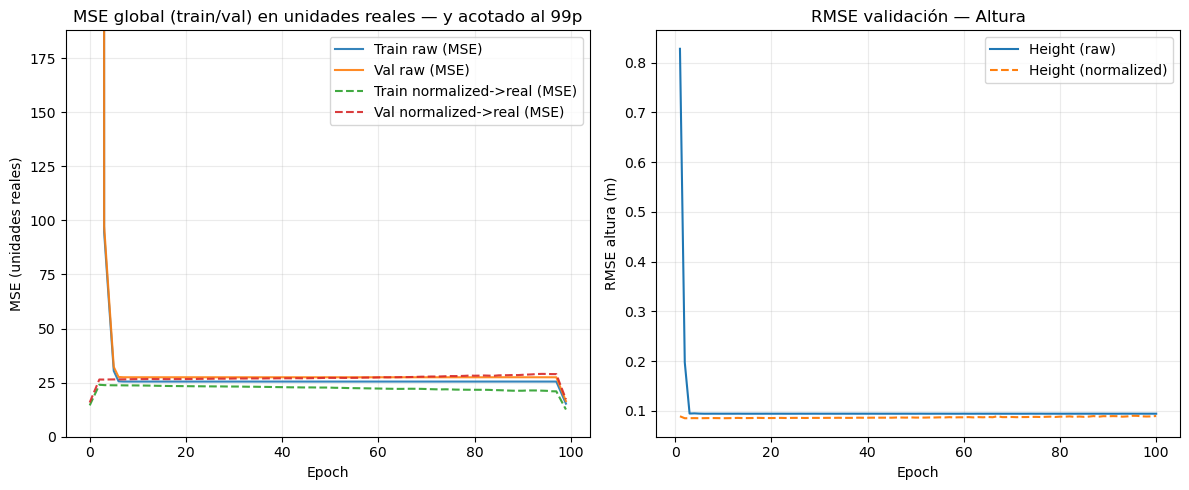

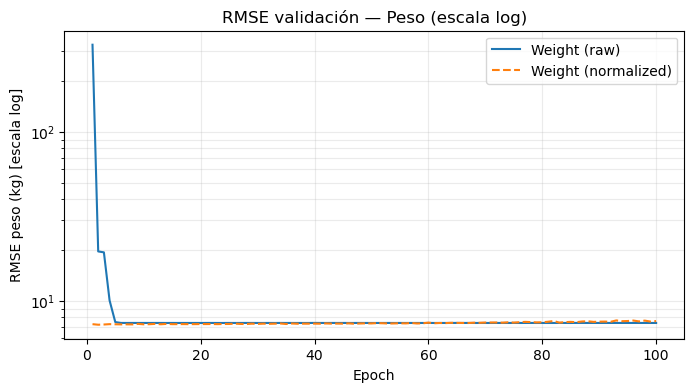

RMSE final (validación) - Modelo A (raw): Height = 0.0942 m, Weight = 7.4116 kg
RMSE final (validación) - Modelo B (normalized): Height = 0.0895 m, Weight = 7.6051 kg
Mejora (porcentual) normalización vs raw: Height = +4.93%, Weight = -2.61%


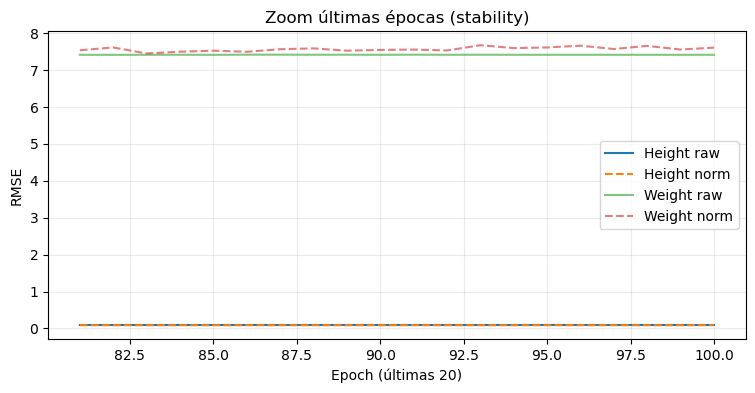

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# funciones auxiliares
def smooth(x, k=5):
    if k <= 1:
        return x
    return np.convolve(x, np.ones(k)/k, mode='same')

# Convertir listas a arrays si no lo son
trainA = np.array(trainA); valA = np.array(valA)
trainB = np.array(trainB); valB = np.array(valB)
rmseA = np.array(val_rmseA)  # (epochs, 2)
rmseB = np.array(val_rmseB)

# 1) Gráfico principal en escala lineal *sin el primer outlier visual*:
# descartamos (o acotamos) los valores excesivos del eje Y para ver la curva real.
ylim_upper = np.percentile(np.concatenate([valA, valB]), 99)  # 99 percentile as visual cap

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(smooth(trainA,5), label='Train raw (MSE)', alpha=0.9)
plt.plot(smooth(valA,5), label='Val raw (MSE)', alpha=0.9)
plt.plot(smooth(trainB,5), '--', label='Train normalized->real (MSE)', alpha=0.9)
plt.plot(smooth(valB,5), '--', label='Val normalized->real (MSE)', alpha=0.9)
plt.ylim(0, max(ylim_upper, 1e-6))       # cap the y-axis to remove huge spikes
plt.xlabel('Epoch'); plt.ylabel('MSE (unidades reales)')
plt.title('MSE global (train/val) en unidades reales — y acotado al 99p')
plt.legend(); plt.grid(alpha=0.25)

# 2) RMSE por salida — usar subplots separados (mejor legibilidad)
plt.subplot(1,2,2)
epochs = np.arange(1, len(rmseA)+1)
plt.plot(epochs, rmseA[:,0], label='Height (raw)'); plt.plot(epochs, rmseB[:,0], '--', label='Height (normalized)')
plt.xlabel('Epoch'); plt.ylabel('RMSE altura (m)'); plt.title('RMSE validación — Altura'); plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 3) Gráfico separado para Weight con escala log si es necesario
plt.figure(figsize=(8,4))
plt.plot(epochs, rmseA[:,1], label='Weight (raw)')
plt.plot(epochs, rmseB[:,1], '--', label='Weight (normalized)')
plt.yscale('log')  # si la escala del peso es grande, usar log ayuda a ver tendencias
plt.xlabel('Epoch'); plt.ylabel('RMSE peso (kg) [escala log]')
plt.title('RMSE validación — Peso (escala log)')
plt.legend(); plt.grid(alpha=0.25, which='both')
plt.show()

# 4) Tabla resumen final + mejora porcentual
final_rmseA = rmseA[-1]; final_rmseB = rmseB[-1]
improvement_h = 100.0 * (final_rmseA[0] - final_rmseB[0]) / (final_rmseA[0] + 1e-12)
improvement_w = 100.0 * (final_rmseA[1] - final_rmseB[1]) / (final_rmseA[1] + 1e-12)
print("RMSE final (validación) - Modelo A (raw): Height = {:.4f} m, Weight = {:.4f} kg".format(final_rmseA[0], final_rmseA[1]))
print("RMSE final (validación) - Modelo B (normalized): Height = {:.4f} m, Weight = {:.4f} kg".format(final_rmseB[0], final_rmseB[1]))
print("Mejora (porcentual) normalización vs raw: Height = {:+.2f}%, Weight = {:+.2f}%".format(improvement_h, improvement_w))

# 5) Zoom final: últimas 20 épocas para comparar estabilidad
last = 20
plt.figure(figsize=(9,4))
plt.plot(epochs[-last:], rmseA[-last:,0], label='Height raw')
plt.plot(epochs[-last:], rmseB[-last:,0], '--', label='Height norm')
plt.plot(epochs[-last:], rmseA[-last:,1], label='Weight raw', alpha=0.6)
plt.plot(epochs[-last:], rmseB[-last:,1], '--', label='Weight norm', alpha=0.6)
plt.xlabel('Epoch (últimas {})'.format(last)); plt.ylabel('RMSE'); plt.title('Zoom últimas épocas (stability)')
plt.legend(); plt.grid(alpha=0.25)
plt.show()
